<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-JeremyDail/blob/main/Exam%20C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Exam C: The Lorenz System

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sigma = 10.0
rho   = 28.0
beta  = 8.0/3.0

def diffeq(u):
    X, Y, Z = u
    Xdot = sigma * (Y - X)
    Ydot = X * (rho - Z) - Y
    Zdot = X * Y - beta * Z
    return np.array([Xdot, Ydot, Zdot])

def euler_step(u, dt):
    return u + dt * diffeq(u)

def rk2_step(u, dt):
    k1 = diffeq(u)
    u_mid = u + 0.5 * dt * k1
    k2 = diffeq(u_mid)
    return u + dt * k2

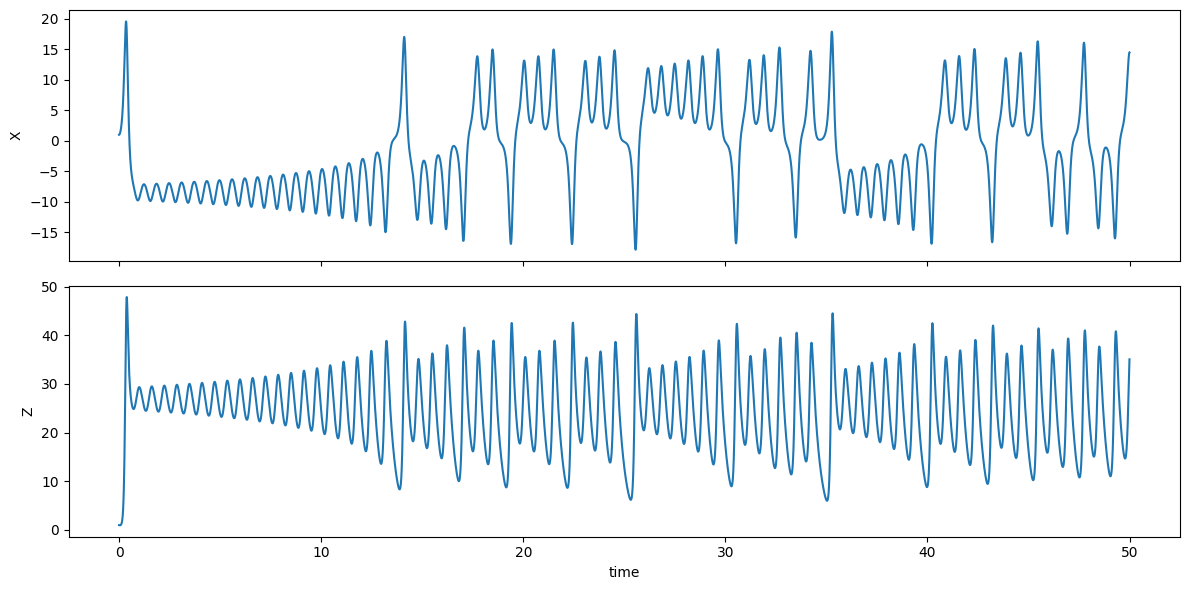

In [3]:
#Part 1

dt = 0.005
t_range = np.arange(0, 50, dt)
u0 = np.array([1.0, 1.0, 1.0])

Xs, Ys, Zs = [], [], []
u = u0.copy()

for t in t_range:
    Xs.append(u[0])
    Ys.append(u[1])
    Zs.append(u[2])
    u = rk2_step(u, dt)

Xs = np.array(Xs)
Ys = np.array(Ys)
Zs = np.array(Zs)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_range, Xs)
axes[1].plot(t_range, Zs)

axes[0].set_ylabel('X')
axes[1].set_ylabel('Z')
axes[1].set_xlabel('time')

plt.tight_layout()
plt.show()


In [4]:
#Motion doesn't look periodic. Oscilations don't repeat in a regular way, but they do stay in a range of values. The system is bounded but not repeating. The variables keep changing in a complicated way without getting too settled into a pattern, thus implying chaotic behavior.

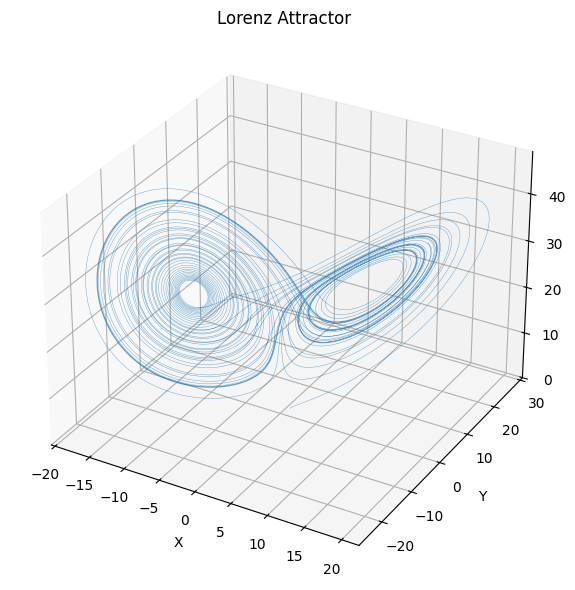

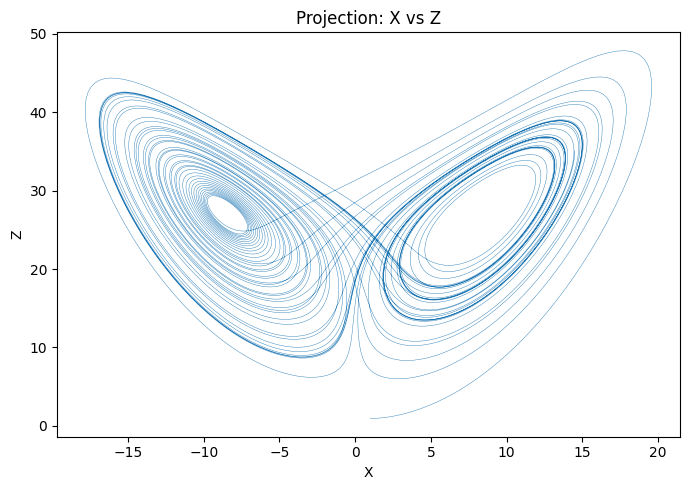

In [5]:
#Part 2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(Xs, Ys, Zs, lw=0.3, alpha=0.7)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Lorenz Attractor')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(Xs, Zs, lw=0.3)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('Projection: X vs Z')
plt.tight_layout()
plt.show()

In [6]:
#Here we see that butterfly shape. The trajectory loops around one lobe for a bit, then switches lobes. It'll do this forever
#It stays on this structure without repeating exactly, thus chaotic. It's not random, due to it staying in the shape, but its not periodic because it doesn't come back and repeat the same path exactly.


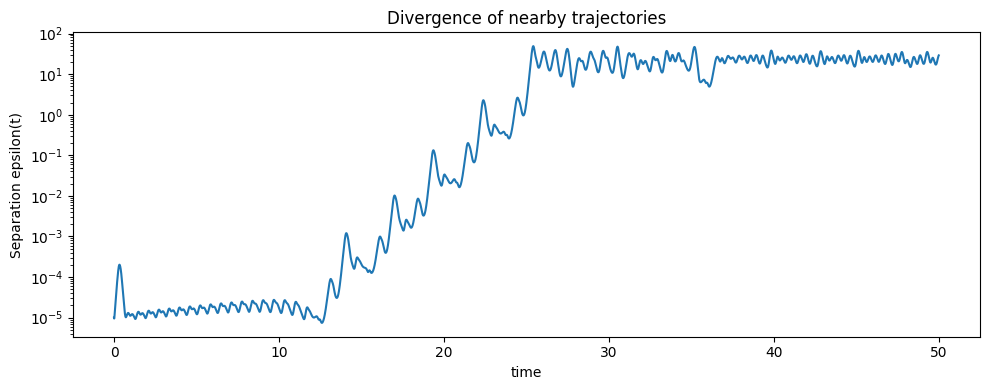

Estimated exponent λ ≈ 0.326
(literature value for Lorenz: λ ≈ 0.906)


In [7]:
#Part 3

dt = 0.005
t_range = np.arange(0, 50, dt)

u0a = np.array([1.0,       1.0, 1.0])
u0b = np.array([1.0+1e-5,  1.0, 1.0])

separations = []

ua = u0a.copy()
ub = u0b.copy()

for t in t_range:
    delta = np.linalg.norm(ua - ub)
    separations.append(delta)
    ua = rk2_step(ua, dt)
    ub = rk2_step(ub, dt)

separations = np.array(separations)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(t_range, separations)
ax.set_xlabel('time')
ax.set_ylabel('Separation epsilon(t)')
ax.set_title('Divergence of nearby trajectories')
plt.tight_layout()
plt.show()

t_early = t_range[t_range < 20]
log_sep = np.log(separations[:len(t_early)])

lam, intercept = np.polyfit(t_early, log_sep, 1)
print(f'Estimated exponent λ ≈ {lam:.3f}')
print('(literature value for Lorenz: λ ≈ 0.906)')


In [8]:
#On the plot, the separation is a straight line early on. This means growth is almost exponential. My estimated exponent came close to the accepted literature value even though it won't match exactly because of finite timestep and fitting.
#Later on, separation levels off. The two trajectories can't keep separating forever.The distance becomes comparable to the size of the attractor and will stop exponentially growing.

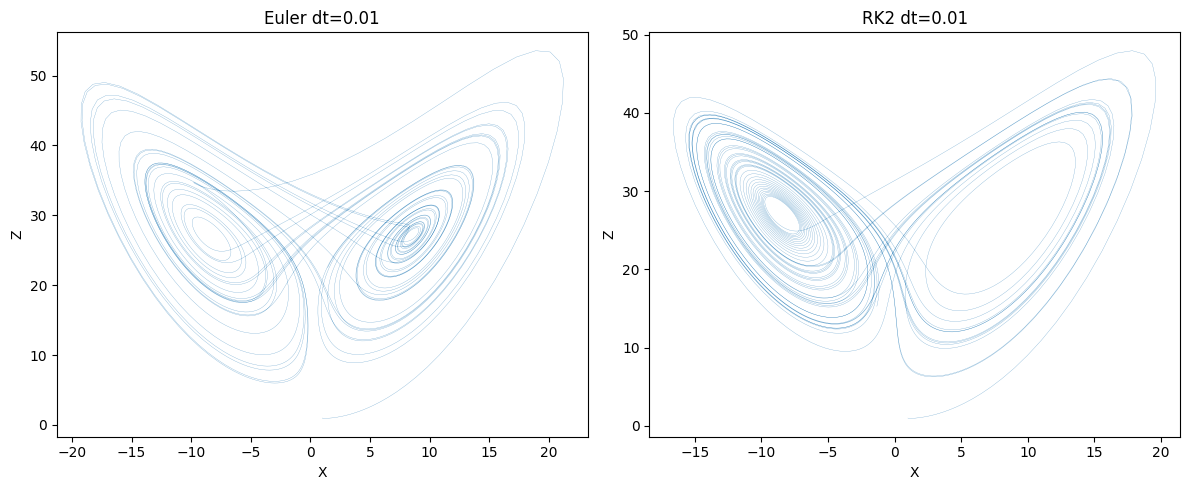

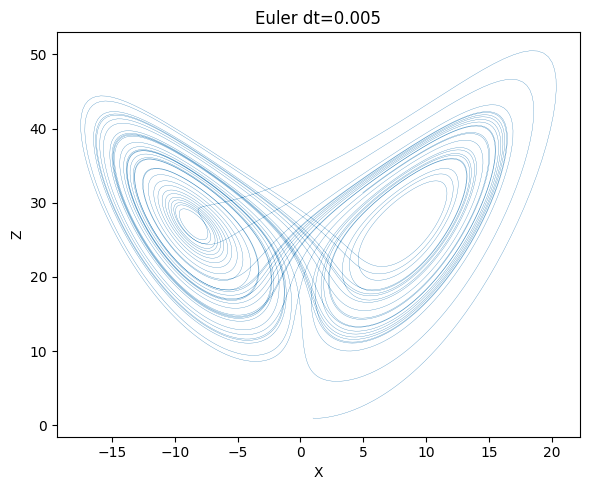

In [9]:
#Part 4
dt = 0.01
t_range = np.arange(0, 40, dt)
u0 = np.array([1.0, 1.0, 1.0])

# Run Euler
Xs_euler, Zs_euler = [], []
u = u0.copy()
for t in t_range:
    Xs_euler.append(u[0])
    Zs_euler.append(u[2])
    u = euler_step(u, dt)

Xs_rk2, Zs_rk2 = [], []
u = u0.copy()
for t in t_range:
    Xs_rk2.append(u[0])
    Zs_rk2.append(u[2])
    u = rk2_step(u, dt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(Xs_euler, Zs_euler, lw=0.2, alpha=0.7)
axes[0].set_title('Euler dt=0.01')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Z')

axes[1].plot(Xs_rk2, Zs_rk2, lw=0.2, alpha=0.7)
axes[1].set_title('RK2 dt=0.01')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
plt.tight_layout()
plt.show()

dt = 0.005
t_range = np.arange(0, 40, dt)

Xs_euler2, Zs_euler2 = [], []
u = u0.copy()
for t in t_range:
    Xs_euler2.append(u[0])
    Zs_euler2.append(u[2])
    u = euler_step(u, dt)

plt.figure(figsize=(6,5))
plt.plot(Xs_euler2, Zs_euler2, lw=0.2)
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Euler dt=0.005')
plt.tight_layout()
plt.show()

In [10]:
#RK2 does elaborates on the lorenz attractor a bit. Euler with the large timestep will distort the shape sometimes. When euler fails, the attractor will look spread out and messed up compared to the butterfly shape.
#Using Euler with a small timestep can kind of help because numerical error is smaller. Chaos does make it hard to compare trajectories though, since even two solutions will separate over time regardless of accuracy. The better test is if the overall shape is reproduced correctly, not if the two paths are consistent.

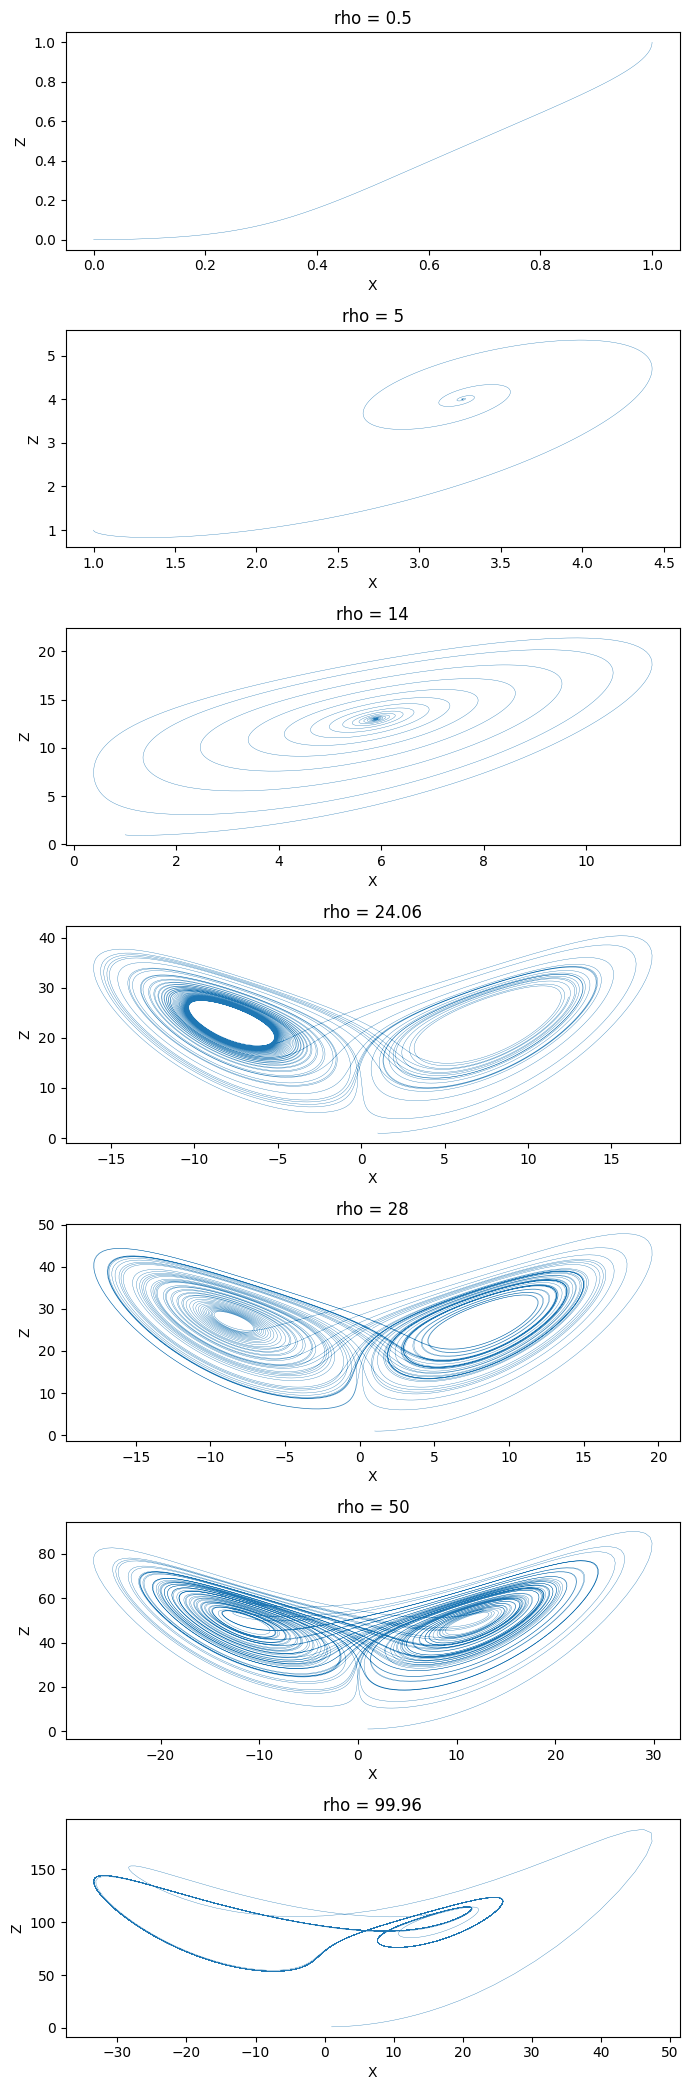

In [11]:
#Part 5

rho_values = [0.5, 5, 14, 24.06, 28, 50, 99.96]

dt = 0.005
t_range = np.arange(0, 60, dt)
u0 = np.array([1.0, 1.0, 1.0])

fig, axes = plt.subplots(len(rho_values), 1, figsize=(7, 3*len(rho_values)))

for i, rho_val in enumerate(rho_values):
    Xs, Zs = [], []
    u = u0.copy()

    for t in t_range:
        Xs.append(u[0])
        Zs.append(u[2])

        X, Y, Z = u
        Xdot = sigma * (Y - X)
        Ydot = X * (rho_val - Z) - Y
        Zdot = X * Y - beta * Z
        k1 = np.array([Xdot, Ydot, Zdot])

        u_mid = u + 0.5 * dt * k1
        Xm, Ym, Zm = u_mid
        Xdot_m = sigma * (Ym - Xm)
        Ydot_m = Xm * (rho_val - Zm) - Ym
        Zdot_m = Xm * Ym - beta * Zm
        k2 = np.array([Xdot_m, Ydot_m, Zdot_m])

        u = u + dt * k2

    axes[i].plot(Xs, Zs, lw=0.25)
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Z')
    axes[i].set_title(f'rho = {rho_val}')


plt.tight_layout()
plt.show()

In [12]:
#For the small values of Rho, the trajectory chills out rather than being chaotic. Later on in the intermediary, the motion  looks more ordered than chaotic. Near the lorenz value of rho, the system shows the chaotic behvaior anticipated
#Chaos appears once Rho becomes large enough, around the 20s.
# When Rho is near 100, the motion looks wildly different because the loops are much larger and the structure changes shape from the butterfly attractor.